In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("data/house_prices.csv")
data.head()

,size_sqft,price
0,500,155000
1,600,185000
2,700,215000
3,800,245000
4,900,275000


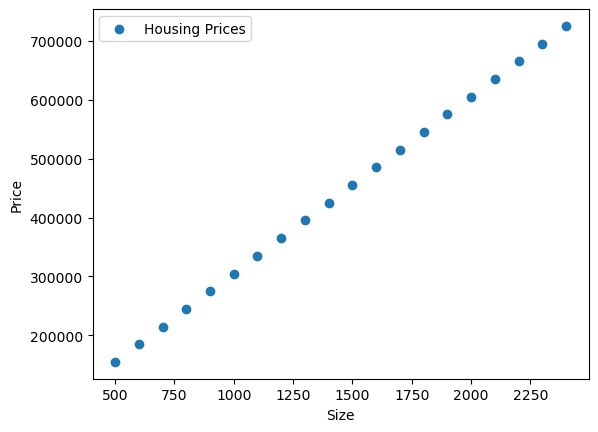

In [3]:
plt.scatter(
    data['size_sqft'],
    data['price'],
    label="Housing Prices"
)
plt.xlabel("Size")
plt.ylabel("Price")
plt.legend()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
x = data[['size_sqft']]
y=data[['price']]
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

x_scalar = StandardScaler()
y_scalar = StandardScaler()

x_train = x_scalar.fit_transform(x_train)
x_test = x_scalar.transform(x_test)

y_train = y_scalar.fit_transform(y_train)
y_test = y_scalar.transform(y_test)

x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

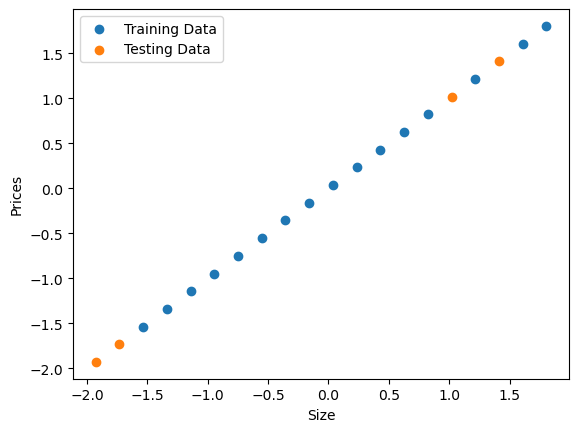

In [6]:
plt.scatter(
    x_train,
    y_train,
    label="Training Data"
)
plt.scatter(
    x_test,
    y_test,
    label="Testing Data"
)
plt.xlabel("Size")
plt.ylabel("Prices")
plt.legend()
plt.show()

In [7]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer = nn.Linear(
            in_features=1,
            out_features=1
        )

    def forward(self, x:torch.Tensor):
        return self.linear_layer(x)
        

In [8]:
model = LinearRegression()

In [9]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[-0.4498]])),
             ('linear_layer.bias', tensor([0.1027]))])

In [57]:
loss_fn = nn.L1Loss()
optimzer = torch.optim.SGD(params=model.parameters(),lr=0.001)

In [58]:
torch.manual_seed(42)

epochs = 1000
training_loss = []
testing_loss = []

for epoch in range(epochs):
    model.train()

    train_pred = model(x_train)
    loss_train = loss_fn(train_pred, y_train)
    training_loss.append(loss_train.item())

    optimzer.zero_grad()

    loss_train.backward()

    optimzer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(x_test)
        loss_test = loss_fn(test_pred, y_test)
        testing_loss.append(loss_test.item())
        if epoch % 100 == 0:
            print(f"Epoch : {epoch} | Training Loss : {loss_train} | Testing Loss : {loss_test}")
        

Epoch : 0 | Training Loss : 0.004006918054074049 | Testing Loss : 0.005910545587539673
Epoch : 100 | Training Loss : 0.0002899640239775181 | Testing Loss : 0.0007353425025939941
Epoch : 200 | Training Loss : 0.0002899640239775181 | Testing Loss : 0.0007353425025939941
Epoch : 300 | Training Loss : 0.0002899640239775181 | Testing Loss : 0.0007353425025939941
Epoch : 400 | Training Loss : 0.0002899640239775181 | Testing Loss : 0.0007353425025939941
Epoch : 500 | Training Loss : 0.0002899640239775181 | Testing Loss : 0.0007353425025939941
Epoch : 600 | Training Loss : 0.0002899640239775181 | Testing Loss : 0.0007353425025939941
Epoch : 700 | Training Loss : 0.0002899640239775181 | Testing Loss : 0.0007353425025939941
Epoch : 800 | Training Loss : 0.0002899640239775181 | Testing Loss : 0.0007353425025939941
Epoch : 900 | Training Loss : 0.0002899640239775181 | Testing Loss : 0.0007353425025939941


In [59]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.9997]])),
             ('linear_layer.bias', tensor([8.3910e-05]))])

In [60]:
with torch.inference_mode():
    pred = model(x_test)

pred

tensor([[-1.9273],
        [ 1.4119],
        [ 1.0190],
        [-1.7309]])

In [61]:
y_test

tensor([[-1.9280],
        [ 1.4122],
        [ 1.0193],
        [-1.7315]])

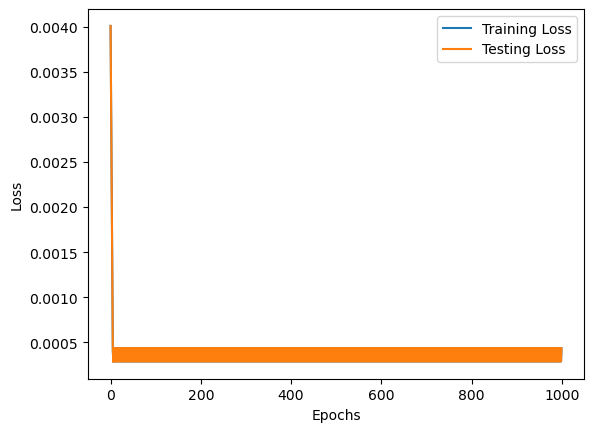

In [62]:
plt.plot(
    range(epochs),
    training_loss,
    label="Training Loss"
)
plt.plot(
    range(epochs),
    training_loss,
    label="Testing Loss"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [66]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

with torch.inference_mode():
    y_pred = model(x_test)

y_true = y_test.detach().numpy()
y_pred = y_pred.detach().numpy()

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"MAE : {mae}")
print(f"MSE : {mse}")
print(f"R²  : {r2}")

MAE : 0.0005034506320953369
MSE : 2.9047390626146807e-07
R²  : 0.9999998807907104
